# Computational variant prioritization: Enformer & AlphaGenome

**Goal:** see MANUSCRIPT_TODO.md for this section.

**Inputs:** variant annotation with alphagenome and enformer scores

**Outputs:** Visualizations and tables summarizing the model performance on all variants (baseline) and different subsets of variants (e.g. allele frequency bins, region activity and variant activity)

---

In [1]:
import ast
import sys
import pandas as pd
import numpy as np  # For potential NaN handling if needed
import os


sys.path.append("../00_helpful_functions")
import helpful_functions as hf

# from importlib import reload
# reload(hf)

# column names
col_name = "name"
col_header = "name"
col_sequence = "sequence"
col_category = "category"
col_class = "class"
col_source = "source"
col_ref = "ref"
col_chr = "chr"
col_start = "start"
col_end = "end"
col_strand = "strand"
col_variant_class = "variant_class"
col_variant_pos = "variant_pos"
col_SPDI = "SPDI"
col_allele = "allele"
col_info = "info"


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]


# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x


import re


def extract_eh38e_number(header):
    # Use regex to find the pattern that starts with EH38E followed by digits
    match = re.search(r"EH38E\d+", header)
    if match:
        return match.group(0)  # Return the matched string
    return None  # Return None if no match is found


import yaml

config_path = "data/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()


### Plan: 
- Load variant predictions from Enformer and AlphaGenome, CADD, chromBPNet, fine-tuned AlphaGenome encoder => summarized for each variant and feature space
- Compare the variant effect predictions from both models to significant variants and variants within regions of activity

### Compare performance based on different scores

In [2]:
_top_region_fraction = 0.05

In [ ]:
variant_predictions_table_path = "./data/2605_NGN2_variants_with_model_predictions_cadd16_cadd17_alphaGenome_encoder_chrombpnet.tsv.gz"
variant_predictions_df = pd.read_csv(variant_predictions_table_path, sep="\t", low_memory=False)
variant_predictions_df

# safe eval of
cols_list = ["gene_set", "enformer_classes_list"]
for col in cols_list:
    variant_predictions_df[col] = variant_predictions_df[col].apply(hf.safe_eval)

In [4]:
# add genomic variant position: from spdi
variant_predictions_df["genomic_variant_position_hg38"] = variant_predictions_df["SPDI"].apply(lambda x: int(x.split(":")[1]))
variant_predictions_df

,ID,chr_pos_ref_alt,SPDI,variant_pos,genomic_variant_pos_hg38,gene_set,associated_gene_name,gnomad_AC,gnomad_AF,af_category,...,alphaGe_encoder_pred_alt,alphaGe_encoder_pred_delta,abs_alphaGe_encoder_pred_delta,alphage_encoder_head_exists,cbp_logfc_mean,cbp_abs_logfc_mean,cbp_jsd_mean,cbp_abs_logfc_x_jsd_mean,has_chrombpnet,genomic_variant_position_hg38
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2192366-T-G,NC_000001.11:2192365:T:G,116,2192365,[neuro],SKI,1.0,0.000007,singleton,...,-1.617188,0.281250,0.281250,True,0.184181,0.184181,0.033900,0.006464,True,2192365
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2193142-G-A,NC_000001.11:2193141:G:A,205,2193141,[neuro],SKI,7205.0,0.047348,common,...,-2.203125,-0.125000,0.125000,True,-0.007199,0.007199,0.009480,0.000069,True,2193141
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2197934-C-A,NC_000001.11:2197933:C:A,71,2197933,[neuro],SKI,1.0,0.000007,singleton,...,-1.125000,0.820312,0.820312,True,0.039190,0.041870,0.017653,0.001127,True,2197933
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2198007-C-G,NC_000001.11:2198006:C:G,144,2198006,[neuro],SKI,4.0,0.000026,rare,...,-1.726562,0.218750,0.218750,True,0.016775,0.016775,0.013647,0.000240,True,2198006
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2198046-G-A,NC_000001.11:2198045:G:A,183,2198045,[neuro],SKI,6.0,0.000039,rare,...,-1.898438,0.046875,0.046875,True,-0.001223,0.008083,0.011389,0.000093,True,2198045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38963,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154545206-A-G,NC_000023.11:154545205:A:G,64,154545205,[cava],G6PD,1.0,0.000009,singleton,...,0.984375,0.046875,0.046875,True,0.013127,0.013127,0.010362,0.000136,True,154545205
38964,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154549923-T-G,NC_000023.11:154549922:T:G,149,154549922,[cava],G6PD,1.0,0.000009,singleton,...,-0.390625,-0.134766,0.134766,True,-0.010027,0.010706,0.014899,0.000160,True,154549922
38965,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154552289-C-T,NC_000023.11:154552288:C:T,126,154552288,[cava],G6PD,1.0,0.000009,singleton,...,0.308594,0.021484,0.021484,True,-0.009268,0.011438,0.010315,0.000131,True,154552288
38966,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154552371-G-A,NC_000023.11:154552370:G:A,44,154552370,[cava],G6PD,2.0,0.000018,rare,...,0.396484,0.109375,0.109375,True,-0.003549,0.003549,0.009195,0.000033,True,154552370


In [5]:
variant_predictions_df.columns.to_list()

['ID',
 'chr_pos_ref_alt',
 'SPDI',
 'variant_pos',
 'genomic_variant_pos_hg38',
 'gene_set',
 'associated_gene_name',
 'gnomad_AC',
 'gnomad_AF',
 'af_category',
 'variant_pos.1',
 'minimal_tss_distance_associated_gene',
 'closest_tss_gene_name',
 'closest_tss_0based',
 'closest_tss_strand',
 'NGN2_variant_adj_p-value',
 'NGN2_variant_logFC',
 'NGN2_variant_has_readout',
 'NGN2_variant_is_significant',
 'NGN2_variant_abs_logFC',
 'NGN2_high_effect_var_09',
 'NGN2_high_effect_var_095',
 'NGN2_region_logFC',
 'NGN2_region_adj_p-value',
 'NGN2_region_normalized_activity',
 'significant_region_NGN2',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_open_chromatin_ngn2_single_cell',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'local_bitscore_delta_local_bit_score',


In [6]:
variant_input_path = "data/2604_variant_effects_with_gnomad_tested_updated_enformer_random.tsv.gz"
NGN2_variants_with_gwas_tested = pd.read_csv(
    variant_input_path,
    sep="\t",
    low_memory=False,
)

# safe eval of
cols_list = ["gene_set", "enformer_classes_list"]
for col in cols_list:
    NGN2_variants_with_gwas_tested[col] = NGN2_variants_with_gwas_tested[col].apply(hf.safe_eval)

In [8]:
NGN2_variants_with_gwas_tested_unique = NGN2_variants_with_gwas_tested.drop_duplicates(subset=["chr_pos_ref_alt"])

In [9]:
variant_predictions_df_current_columns = variant_predictions_df.columns.to_list()

In [10]:
# add the updated enformer information
variant_predictions_df = (
    variant_predictions_df
).drop(columns=["enformer_classes_list", "enformer_class"])
variant_predictions_df = variant_predictions_df.merge(
    NGN2_variants_with_gwas_tested_unique[
        ["chr_pos_ref_alt", "enformer_classes_list", "enformer_class"]
    ],
    on="chr_pos_ref_alt",
    how="left",
)

variant_predictions_df = variant_predictions_df[variant_predictions_df_current_columns].copy()
variant_predictions_df

,ID,chr_pos_ref_alt,SPDI,variant_pos,genomic_variant_pos_hg38,gene_set,associated_gene_name,gnomad_AC,gnomad_AF,af_category,...,alphaGe_encoder_pred_alt,alphaGe_encoder_pred_delta,abs_alphaGe_encoder_pred_delta,alphage_encoder_head_exists,cbp_logfc_mean,cbp_abs_logfc_mean,cbp_jsd_mean,cbp_abs_logfc_x_jsd_mean,has_chrombpnet,genomic_variant_position_hg38
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2192366-T-G,NC_000001.11:2192365:T:G,116,2192365,[neuro],SKI,1.0,0.000007,singleton,...,-1.617188,0.281250,0.281250,True,0.184181,0.184181,0.033900,0.006464,True,2192365
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2193142-G-A,NC_000001.11:2193141:G:A,205,2193141,[neuro],SKI,7205.0,0.047348,common,...,-2.203125,-0.125000,0.125000,True,-0.007199,0.007199,0.009480,0.000069,True,2193141
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2197934-C-A,NC_000001.11:2197933:C:A,71,2197933,[neuro],SKI,1.0,0.000007,singleton,...,-1.125000,0.820312,0.820312,True,0.039190,0.041870,0.017653,0.001127,True,2197933
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2198007-C-G,NC_000001.11:2198006:C:G,144,2198006,[neuro],SKI,4.0,0.000026,rare,...,-1.726562,0.218750,0.218750,True,0.016775,0.016775,0.013647,0.000240,True,2198006
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2198046-G-A,NC_000001.11:2198045:G:A,183,2198045,[neuro],SKI,6.0,0.000039,rare,...,-1.898438,0.046875,0.046875,True,-0.001223,0.008083,0.011389,0.000093,True,2198045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38963,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154545206-A-G,NC_000023.11:154545205:A:G,64,154545205,[cava],G6PD,1.0,0.000009,singleton,...,0.984375,0.046875,0.046875,True,0.013127,0.013127,0.010362,0.000136,True,154545205
38964,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154549923-T-G,NC_000023.11:154549922:T:G,149,154549922,[cava],G6PD,1.0,0.000009,singleton,...,-0.390625,-0.134766,0.134766,True,-0.010027,0.010706,0.014899,0.000160,True,154549922
38965,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154552289-C-T,NC_000023.11:154552288:C:T,126,154552288,[cava],G6PD,1.0,0.000009,singleton,...,0.308594,0.021484,0.021484,True,-0.009268,0.011438,0.010315,0.000131,True,154552288
38966,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154552371-G-A,NC_000023.11:154552370:G:A,44,154552370,[cava],G6PD,2.0,0.000018,rare,...,0.396484,0.109375,0.109375,True,-0.003549,0.003549,0.009195,0.000033,True,154552370


In [12]:
if not "minimal_tss_distance_associated_gene" in variant_predictions_df.columns:
    raise ValueError("Expected column not found")

In [17]:
def compute_tss_distance(row, variant_pos_column="genomic_variant_position_hg38", tss_pos_column="closest_tss_0based"):
    if pd.isna(row[tss_pos_column]):
        return np.nan
    return abs(row[variant_pos_column] - row[tss_pos_column])

def upstream_downstream_with_strand(row, variant_pos_column="genomic_variant_position_hg38", tss_pos_column="closest_tss_0based", strand_column="closest_tss_strand"):
    if pd.isna(row[tss_pos_column]) or pd.isna(row[strand_column]):
        return np.nan
    if row[variant_pos_column] < row[tss_pos_column]:
        # variant is upstream of TSS
        return "upstream" if row[strand_column] == "+" else "downstream"
    else:
        # variant is downstream of TSS
        return "downstream" if row[strand_column] == "+" else "upstream"

In [18]:
variant_predictions_df["variant_location_relative_to_tss"] = variant_predictions_df.apply(
    upstream_downstream_with_strand, axis=1
)

variant_predictions_df["tss_distance"] = variant_predictions_df.apply(
    compute_tss_distance, axis=1
)

In [19]:
variant_predictions_df.columns.to_list()

['ID',
 'chr_pos_ref_alt',
 'SPDI',
 'variant_pos',
 'genomic_variant_pos_hg38',
 'gene_set',
 'associated_gene_name',
 'gnomad_AC',
 'gnomad_AF',
 'af_category',
 'variant_pos.1',
 'minimal_tss_distance_associated_gene',
 'closest_tss_gene_name',
 'closest_tss_0based',
 'closest_tss_strand',
 'NGN2_variant_adj_p-value',
 'NGN2_variant_logFC',
 'NGN2_variant_has_readout',
 'NGN2_variant_is_significant',
 'NGN2_variant_abs_logFC',
 'NGN2_high_effect_var_09',
 'NGN2_high_effect_var_095',
 'NGN2_region_logFC',
 'NGN2_region_adj_p-value',
 'NGN2_region_normalized_activity',
 'significant_region_NGN2',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_open_chromatin_ngn2_single_cell',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'local_bitscore_delta_local_bit_score',


In [20]:
tested_variant_predictions_df = variant_predictions_df.loc[
    variant_predictions_df["ID"].str.contains("cardiac_neuro_cava_random:")
].copy()
tested_variant_predictions_df

,ID,chr_pos_ref_alt,SPDI,variant_pos,genomic_variant_pos_hg38,gene_set,associated_gene_name,gnomad_AC,gnomad_AF,af_category,...,alphage_encoder_head_exists,cbp_logfc_mean,cbp_abs_logfc_mean,cbp_jsd_mean,cbp_abs_logfc_x_jsd_mean,has_chrombpnet,genomic_variant_position_hg38,pubmed_abstract_count,variant_location_relative_to_tss,tss_distance
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2192366-T-G,NC_000001.11:2192365:T:G,116,2192365,[neuro],SKI,1.0,0.000007,singleton,...,True,0.184181,0.184181,0.033900,0.006464,True,2192365,4120,upstream,35022.0
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2193142-G-A,NC_000001.11:2193141:G:A,205,2193141,[neuro],SKI,7205.0,0.047348,common,...,True,-0.007199,0.007199,0.009480,0.000069,True,2193141,4120,upstream,34246.0
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2197934-C-A,NC_000001.11:2197933:C:A,71,2197933,[neuro],SKI,1.0,0.000007,singleton,...,True,0.039190,0.041870,0.017653,0.001127,True,2197933,4120,upstream,29454.0
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2198007-C-G,NC_000001.11:2198006:C:G,144,2198006,[neuro],SKI,4.0,0.000026,rare,...,True,0.016775,0.016775,0.013647,0.000240,True,2198006,4120,upstream,29381.0
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2198046-G-A,NC_000001.11:2198045:G:A,183,2198045,[neuro],SKI,6.0,0.000039,rare,...,True,-0.001223,0.008083,0.011389,0.000093,True,2198045,4120,upstream,29342.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38963,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154545206-A-G,NC_000023.11:154545205:A:G,64,154545205,[cava],G6PD,1.0,0.000009,singleton,...,True,0.013127,0.013127,0.010362,0.000136,True,154545205,7381,downstream,903.0
38964,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154549923-T-G,NC_000023.11:154549922:T:G,149,154549922,[cava],G6PD,1.0,0.000009,singleton,...,True,-0.010027,0.010706,0.014899,0.000160,True,154549922,7381,upstream,2351.0
38965,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154552289-C-T,NC_000023.11:154552288:C:T,126,154552288,[cava],G6PD,1.0,0.000009,singleton,...,True,-0.009268,0.011438,0.010315,0.000131,True,154552288,7381,upstream,4717.0
38966,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154552371-G-A,NC_000023.11:154552370:G:A,44,154552370,[cava],G6PD,2.0,0.000018,rare,...,True,-0.003549,0.003549,0.009195,0.000033,True,154552370,7381,upstream,4799.0


#### Performance for variant prioritization: 
- Is cell-type specific information supperior for variant prioritization?

In [16]:
df = variant_predictions_df.copy()

#### Cleaned code: 

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score


def compute_global_effect_threshold(
    df,
    effect_col="NGN2_variant_abs_logFC",
    top_frac=0.1,
):
    """
    Compute a global high-effect threshold across all measured variants.
    """
    d = df[df["NGN2_variant_has_readout"] == True]
    thr = d[effect_col].quantile(1 - top_frac)
    return thr

CFG = {
    "has_readout": "NGN2_variant_has_readout",
    "active_region": "significant_region_NGN2",
    "sig_label": "NGN2_variant_is_significant",
    "af": "gnomad_AF",
    "ac": "gnomad_AC",
    "activity": "NGN2_region_normalized_activity",
    "effect": "NGN2_variant_abs_logFC",
    "brain_screen_cCRE": "is_brain_SCREEN_cCRE",
    "NGN2_open_chromatin_bulk_ATAC": "is_ngn2_atac_overlap",
}


def filter_all(df):
    return df[df[CFG["has_readout"]] == True].copy()

def filter_all_measured(df):
    return df[df["NGN2_variant_has_readout"] == True].copy()


def filter_significant(df):
    d = df[df["NGN2_variant_has_readout"] == True].copy()
    d = d[d["NGN2_variant_is_significant"] == True]
    return d


def filter_sig_active(df):
    d = df[df["NGN2_variant_has_readout"] == True].copy()
    d = d[d["NGN2_variant_is_significant"] == True]
    d = d[d["significant_region_NGN2"] == True]
    return d


def filter_active(df):
    d = filter_all(df)
    return d[d[CFG["active_region"]] == True].copy()


def filter_brain_screen(df):
    d = filter_all(df)
    return d[d[CFG["brain_screen_cCRE"]] == True].copy()


def filter_open_chromatin_NGN2(df):
    d = filter_all(df)
    return d[d[CFG["NGN2_open_chromatin_bulk_ATAC"]] == True].copy()


def make_effect_label_top_frac(d, effect_col="NGN2_variant_abs_logFC", top_frac=0.30):
    """Binary label: top X% absolute variant effect size within the provided dataframe."""
    thr = d[effect_col].quantile(1 - top_frac)
    return (d[effect_col] >= thr).astype(int), thr


def make_effect_label_global(
    d,
    global_thr,
    effect_col="NGN2_variant_abs_logFC",
):
    """
    Binary label using a GLOBAL effect-size threshold.
    """
    return (d[effect_col] >= global_thr).astype(int)


def make_sig_label(d, sig_col="NGN2_variant_is_significant"):
    return d[sig_col].astype(int)


def compute_auc(y, s):
    """
    ROC AUC with guards against degenerate inputs.
    """
    y = pd.Series(y).dropna()
    s = pd.Series(s).loc[y.index].dropna()
    y = y.loc[s.index]

    if y.nunique() < 2:
        return np.nan

    return roc_auc_score(y, s)


def compute_auc_summary(
    df,
    universes,
    model_scores,
    label_type="effect_global",  # effect_global | effect_local | significance
    top_frac=0.05,
    global_effect_thr=None,
):
    """
    Compute AUCs for multiple universes and models.

    label_type:
      - effect_global : uses ONE global effect-size threshold (recommended default)
      - effect_local  : uses top_frac within each universe
      - significance  : significant vs non-significant
    """

    rows = []

    for u_name, u_fn in universes.items():
        d = u_fn(df)

        # Skip tiny universes
        if len(d) < 50:
            continue

        if label_type == "effect_global":
            if global_effect_thr is None:
                raise ValueError(
                    "global_effect_thr must be provided for label_type='effect_global'"
                )
            y = make_effect_label_global(
                d,
                global_thr=global_effect_thr,
                effect_col="NGN2_variant_abs_logFC",
            )
            label_desc = "global high-effect"

        elif label_type == "effect_local":
            y, thr = make_effect_label_top_frac(
                d,
                effect_col="NGN2_variant_abs_logFC",
                top_frac=top_frac,
            )
            label_desc = f"local top {int(top_frac*100)}% (thr={thr:.3g})"

        elif label_type == "significance":
            y = make_sig_label(d)
            label_desc = "significant vs non-significant"

            # Skip universes with only one class
            if y.nunique() < 2:
                continue

        else:
            raise ValueError("Invalid label_type")

        for model, score_col in model_scores.items():
            s = d[score_col]
            auc_val = compute_auc(y, s)

            rows.append(
                {
                    "universe": u_name,
                    "model": model,
                    "score_col": score_col,
                    "AUC": auc_val,
                    "n": len(d),
                    "label": label_desc,
                }
            )

    return pd.DataFrame(rows)


def add_delta_vs_baseline(res_df, baseline="U0_all"):
    """
    Compute ΔAUC relative to baseline universe.
    """
    res = res_df.copy()

    base = (
        res_df[res_df["universe"] == baseline]
        .dropna(subset=["AUC"])
        .set_index("model")["AUC"]
    )

    def delta(row):
        if pd.isna(row["AUC"]):
            return np.nan
        return row["AUC"] - base.get(row["model"], np.nan)

    res["delta_AUC_vs_U0"] = res.apply(delta, axis=1)
    return res

In [ ]:
MODEL_SCORES = {
    "AlphaGenome (mean |Δ|)": "alphaGe_global_mean_abs",
    "AlphaGenome (max |Δ|)": "alphaGe_global_max_abs",
    "Enformer (mean |Δ|)": "enf_norm_global_mean_abs",
    "Enformer (max |Δ|)": "enf_norm_global_max_abs",
    "CADD 1.7 (PHRED)": "CADD17_PHRED",
    "AlphaGenome Encoder* (|Δ|)": "abs_alphaGe_encoder_pred_delta",
    "NGN2 chromBPNet** (Δ)": "cbp_logfc_mean",
    "NGN2 chromBPNet** (|Δ|)": "cbp_abs_logfc_mean",
}
MODEL_SCORES = {
    "AlphaGenome (mean |Δ|)": "alphaGe_global_mean_abs",
    "AlphaGenome (max |Δ|)": "alphaGe_global_max_abs",
    "Enformer (mean |Δ|)": "enf_norm_global_mean_abs",
    "Enformer (max |Δ|)": "enf_norm_global_max_abs",
    "CADD 1.7 (PHRED)": "CADD17_PHRED",
    "AlphaGenome Encoder* (|Δ|)": "abs_alphaGe_encoder_pred_delta",
    "NGN2 chromBPNet** (|Δ|)": "cbp_abs_logfc_mean",
}


MODEL_COLORS = {
    "AlphaGenome (mean |Δ|)": "#662506",
    "AlphaGenome (max |Δ|)": "#993404",
    "Enformer (mean |Δ|)": "#cc4c02",
    "Enformer (max |Δ|)": "#ec7014",
    "CADD 1.7 (PHRED)": "#fe9929",
    "AlphaGenome Encoder* (|Δ|)": "#bd0026",
    "NGN2 chromBPNet** (Δ)": "#8c510a",
    "NGN2 chromBPNet** (|Δ|)": "#d8b365",
}
MODEL_COLORS = {
    "AlphaGenome (mean |Δ|)": "#662506",
    "AlphaGenome (max |Δ|)": "#993404",
    "Enformer (mean |Δ|)": "#cc4c02",
    "Enformer (max |Δ|)": "#ec7014",
    "CADD 1.7 (PHRED)": "#fe9929",
    "AlphaGenome Encoder* (|Δ|)": "#bd0026",
    "NGN2 chromBPNet** (|Δ|)": "#01665e",
}
# 260616: color update
MODEL_COLORS = {
    "AlphaGenome (mean |Δ|)": "#35978f",
    "AlphaGenome (max |Δ|)": "#80cdc1",
    "Enformer (mean |Δ|)": "#543005",
    "Enformer (max |Δ|)": "#bf812d",
    "CADD 1.7 (PHRED)": "#de77ae", # "#dfc27d",
    "AlphaGenome Encoder* (|Δ|)": "#003c30",
    "NGN2 chromBPNet** (|Δ|)": "#bd0026",
}


UNIVERSES = {
    "all": filter_all,
    "significant": filter_significant,
    "active": filter_active,
    "sig_active": filter_sig_active,
    "brain_screen": filter_brain_screen,
    "open_chromatin_NGN2": filter_open_chromatin_NGN2,
}

In [19]:
GLOBAL_EFFECT_THR = compute_global_effect_threshold(df, top_frac=_top_region_fraction)

In [20]:
summary_effect = compute_auc_summary(
    df,
    UNIVERSES,
    MODEL_SCORES,
    label_type="effect_global",
    global_effect_thr=GLOBAL_EFFECT_THR,
    top_frac=_top_region_fraction,
)

summary_sig = compute_auc_summary(
    df,
    UNIVERSES,
    MODEL_SCORES,
    label_type="significance",
)

In [21]:
print(summary_effect.to_string())

               universe                       model                       score_col       AUC      n               label
0                   all      AlphaGenome (mean |Δ|)         alphaGe_global_mean_abs  0.547779  38968  global high-effect
1                   all       AlphaGenome (max |Δ|)          alphaGe_global_max_abs  0.560388  38968  global high-effect
2                   all         Enformer (mean |Δ|)        enf_norm_global_mean_abs  0.530941  38968  global high-effect
3                   all          Enformer (max |Δ|)         enf_norm_global_max_abs  0.504805  38968  global high-effect
4                   all            CADD 1.7 (PHRED)                    CADD17_PHRED  0.503386  38968  global high-effect
5                   all  AlphaGenome Encoder* (|Δ|)  abs_alphaGe_encoder_pred_delta  0.694451  38968  global high-effect
6                   all     NGN2 chromBPNet** (|Δ|)              cbp_abs_logfc_mean  0.538389  38968  global high-effect
7           significant      Alp

In [22]:
summary_sig

,universe,model,score_col,AUC,n,label
0,all,AlphaGenome (mean |Δ|),alphaGe_global_mean_abs,0.570288,38968,significant vs non-significant
1,all,AlphaGenome (max |Δ|),alphaGe_global_max_abs,0.580981,38968,significant vs non-significant
2,all,Enformer (mean |Δ|),enf_norm_global_mean_abs,0.577960,38968,significant vs non-significant
3,all,Enformer (max |Δ|),enf_norm_global_max_abs,0.515608,38968,significant vs non-significant
4,all,CADD 1.7 (PHRED),CADD17_PHRED,0.516588,38968,significant vs non-significant
5,all,AlphaGenome Encoder* (|Δ|),abs_alphaGe_encoder_pred_delta,0.776236,38968,significant vs non-significant
6,all,NGN2 chromBPNet** (|Δ|),cbp_abs_logfc_mean,0.579737,38968,significant vs non-significant
7,active,AlphaGenome (mean |Δ|),alphaGe_global_mean_abs,0.620953,2711,significant vs non-significant
8,active,AlphaGenome (max |Δ|),alphaGe_global_max_abs,0.604857,2711,significant vs non-significant
9,active,Enformer (mean |Δ|),enf_norm_global_mean_abs,0.612256,2711,significant vs non-significant


In [23]:
def add_delta_vs_baseline(res_df, baseline="all"):
    res = res_df.copy()

    base = (
        res_df[res_df["universe"] == baseline]
        .dropna(subset=["AUC"])
        .set_index("model")["AUC"]
    )

    def delta(row):
        if pd.isna(row["AUC"]):
            return np.nan
        return row["AUC"] - base.get(row["model"], np.nan)

    res["delta_AUC_vs_all"] = res.apply(delta, axis=1)
    return res

In [24]:
summary_effect = add_delta_vs_baseline(summary_effect)
summary_sig = add_delta_vs_baseline(summary_sig)

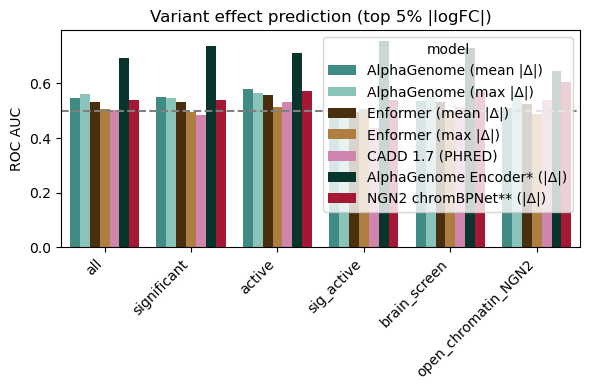

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(
    data=summary_effect,
    x="universe",
    y="AUC",
    hue="model",
    palette=MODEL_COLORS
)
plt.axhline(0.5, ls="--", c="gray")
plt.ylabel("ROC AUC")
plt.xlabel("")
plt.title(f"Variant effect prediction (top {int(_top_region_fraction*100)}% |logFC|)")
# rotate x labels
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
summary_effect

,universe,model,score_col,AUC,n,label,delta_AUC_vs_all
0,all,AlphaGenome (mean |Δ|),alphaGe_global_mean_abs,0.547779,38968,global high-effect,0.000000
1,all,AlphaGenome (max |Δ|),alphaGe_global_max_abs,0.560388,38968,global high-effect,0.000000
2,all,Enformer (mean |Δ|),enf_norm_global_mean_abs,0.530941,38968,global high-effect,0.000000
3,all,Enformer (max |Δ|),enf_norm_global_max_abs,0.504805,38968,global high-effect,0.000000
4,all,CADD 1.7 (PHRED),CADD17_PHRED,0.503386,38968,global high-effect,0.000000
5,all,AlphaGenome Encoder* (|Δ|),abs_alphaGe_encoder_pred_delta,0.694451,38968,global high-effect,0.000000
6,all,NGN2 chromBPNet** (|Δ|),cbp_abs_logfc_mean,0.538389,38968,global high-effect,0.000000
7,significant,AlphaGenome (mean |Δ|),alphaGe_global_mean_abs,0.551546,1018,global high-effect,0.003767
8,significant,AlphaGenome (max |Δ|),alphaGe_global_max_abs,0.547989,1018,global high-effect,-0.012399
9,significant,Enformer (mean |Δ|),enf_norm_global_mean_abs,0.531549,1018,global high-effect,0.000608


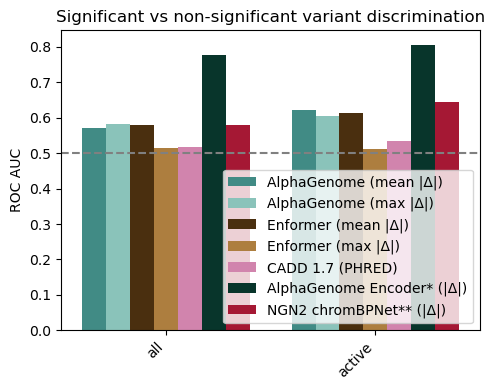

In [27]:
plot_sig_df = summary_sig[summary_sig["universe"].isin(["all", "active"])].copy()

plt.figure(figsize=(5, 4))
sns.barplot(data=plot_sig_df, x="universe", y="AUC", hue="model", palette=MODEL_COLORS)
plt.axhline(0.5, ls="--", c="gray")
plt.ylabel("ROC AUC")
plt.xlabel("")
plt.title("Significant vs non-significant variant discrimination")
# legend at lower right
plt.legend(loc="lower right")
# rotate x labels
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Investigate how additional informations like the knowledge of their allele frequency, the regions activity and their measured effect strength can help improve model performance

In [28]:
print(df.shape)

(38968, 185)


In [29]:
# allele frequency info
df["af_category"].unique()

array(['singleton', 'common', 'rare', 'very common'], dtype=object)

#### Adding Confidence intervals, Precision recall, calibration and effect-size correlation

In [30]:
# Goal: central config + imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm

RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

CFG = {
    "has_readout": "NGN2_variant_has_readout",
    "active_region": "significant_region_NGN2",
    "sig_label": "NGN2_variant_is_significant",
    "af": "gnomad_AF",
    "ac": "gnomad_AC",
    "activity": "NGN2_region_normalized_activity",
    "effect": "NGN2_variant_abs_logFC",
    "brain_screen_cCRE": "is_brain_SCREEN_cCRE",
    "NGN2_open_chromatin_bulk_ATAC": "is_ngn2_atac_overlap",
}


def add_af_category(d):
    """
    Assign allele frequency categories using gnomAD AF and AC.

    Categories:
      - very common: AF ≥ 0.05
      - common:      0.01 ≤ AF < 0.05
      - rare:        AF < 0.01 & AC > 1
      - singleton:   AC == 1
    """

    af = d[CFG["af"]]
    ac = d[CFG["ac"]]

    cat = pd.Series(index=d.index, dtype="object")

    # singleton first (most specific)
    cat[ac == 1] = "singleton"

    # rare (exclude singletons)
    cat[(ac > 1) & (af <= 0.01)] = "rare"

    # common
    cat[(af > 0.01) & (af < 0.05)] = "common"

    # very common
    cat[af >= 0.05] = "very common"

    d = d.copy()
    d["af_category"] = pd.Categorical(
        cat,
        categories=["very common", "common", "rare", "singleton"],
        ordered=True,
    )

    return d

In [31]:
# Goal: define evaluation universes

def filter_all(df):
    return df[df[CFG["has_readout"]] == True].copy()

def filter_active(df):
    d = filter_all(df)
    return d[d[CFG["active_region"]] == True].copy()

def filter_brain_screen(df):
    d = filter_all(df)
    return d[d[CFG["brain_screen_cCRE"]] == True].copy()

def filter_open_chromatin_NGN2(df):
    d = filter_all(df)
    return d[d[CFG["NGN2_open_chromatin_bulk_ATAC"]] == True].copy()

UNIVERSES = {
    "all": filter_all,
    "active": filter_active,
    "brain cCREs": filter_brain_screen,
    "NGN2 open chromatin": filter_open_chromatin_NGN2,
}


def get_label(d):
    return d[CFG["sig_label"]].astype(int)

In [32]:
# Goal: stratified bootstrap CI for ROC-AUC and PR-AUC


def safe_align(y, s):
    y = pd.Series(y)
    s = pd.Series(s)
    idx = y.dropna().index.intersection(s.dropna().index)
    return y.loc[idx].astype(int), s.loc[idx]


def bootstrap_ci(y, s, metric_fn, n_boot=2000):
    y, s = safe_align(y, s)
    if y.nunique() < 2:
        return np.nan, np.nan, np.nan

    point = metric_fn(y, s)
    pos = np.where(y.values == 1)[0]
    neg = np.where(y.values == 0)[0]

    boots = []
    for _ in range(n_boot):
        bpos = rng.choice(pos, size=len(pos), replace=True)
        bneg = rng.choice(neg, size=len(neg), replace=True)
        idx = np.concatenate([bpos, bneg])
        boots.append(metric_fn(y.values[idx], s.values[idx]))

    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


def roc_fn(y, s):
    return roc_auc_score(y, s)


def pr_fn(y, s):
    return average_precision_score(y, s)


def add_black_errorbars(
    ax,
    df,
    x_col,
    y_col,
    lo_col,
    hi_col,
    x_order,
    hue_col="model",
    hue_order=None,
    dodge=0.4,
    capsize=0,
):
    """
    Add perfectly aligned black error bars to a seaborn pointplot
    that uses dodge.
    """

    if hue_order is None:
        hue_order = df[hue_col].unique().tolist()

    n_hue = len(hue_order)

    if n_hue == 1:
        offsets = np.array([0.0])
    else:
        offsets = np.linspace(-dodge / 2, dodge / 2, n_hue)

    x_to_i = {x: i for i, x in enumerate(x_order)}
    hue_to_offset = {h: offsets[i] for i, h in enumerate(hue_order)}

    for _, r in df.iterrows():
        if pd.isna(r[y_col]) or pd.isna(r[lo_col]) or pd.isna(r[hi_col]):
            continue

        x = x_to_i[r[x_col]] + hue_to_offset[r[hue_col]]
        y = r[y_col]

        ax.errorbar(
            x,
            y,
            yerr=[[y - r[lo_col]], [r[hi_col] - y]],
            fmt="none",
            ecolor="black",
            elinewidth=1,
            capsize=capsize,
            zorder=5,
        )

In [33]:
brain_cCREs = df.loc[df[CFG["brain_screen_cCRE"]] == True].copy()
brain_cCREs
# open_chrom_ngn2 = df.loc[df[CFG["NGN2_open_chromatin_bulk_ATAC"]] == True].copy()
# open_chrom_ngn2

,ID,chr_pos_ref_alt,SPDI,variant_pos,genomic_variant_pos_hg38,gene_set,associated_gene_name,gnomad_AC,gnomad_AF,af_category,...,alphaGe_encoder_pred_alt,alphaGe_encoder_pred_delta,abs_alphaGe_encoder_pred_delta,alphage_encoder_head_exists,cbp_logfc_mean,cbp_abs_logfc_mean,cbp_jsd_mean,cbp_abs_logfc_x_jsd_mean,has_chrombpnet,genomic_variant_position_hg38
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2192366-T-G,NC_000001.11:2192365:T:G,116,2192365,[neuro],SKI,1.0,0.000007,singleton,...,-1.617188,0.281250,0.281250,True,0.184181,0.184181,0.033900,0.006464,True,2192365
17,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2236915-C-T,NC_000001.11:2236914:C:T,170,2236914,[neuro],SKI,2.0,0.000013,rare,...,0.404297,-0.158203,0.158203,True,0.005907,0.027709,0.011853,0.000344,True,2236914
18,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2236920-G-A,NC_000001.11:2236919:G:A,175,2236919,[neuro],SKI,5491.0,0.036081,common,...,0.726562,0.164062,0.164062,True,-0.011185,0.015186,0.007769,0.000143,True,2236919
19,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2237274-C-T,NC_000001.11:2237273:C:T,32,2237273,[neuro],SKI,20391.0,0.134104,very common,...,-1.921875,-0.085938,0.085938,True,-0.040142,0.040142,0.011747,0.000476,True,2237273
20,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1-2237341-T-C,NC_000001.11:2237340:T:C,99,2237340,[neuro],SKI,1.0,0.000007,singleton,...,-1.914062,-0.078125,0.078125,True,-0.018624,0.020429,0.011913,0.000256,True,2237340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38903,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,X-154401221-C-T,NC_000023.11:154401220:C:T,32,154401220,[cardiac],FLNA,1982.0,0.017701,common,...,0.195312,0.052734,0.052734,True,-0.046441,0.046441,0.015805,0.000753,True,154401220
38959,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154539177-A-G,NC_000023.11:154539176:A:G,148,154539176,[cava],G6PD,1.0,0.000009,singleton,...,0.037354,-0.036377,0.036377,True,-0.005248,0.005248,0.011384,0.000061,True,154539176
38960,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154539216-G-A,NC_000023.11:154539215:G:A,109,154539215,[cava],G6PD,462.0,0.004132,rare,...,-0.015747,-0.089478,0.089478,True,-0.000683,0.004676,0.012434,0.000061,True,154539215
38961,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X-154539241-G-C,NC_000023.11:154539240:G:C,84,154539240,[cava],G6PD,1879.0,0.016837,common,...,0.164062,0.090332,0.090332,True,0.052059,0.052059,0.025852,0.001530,True,154539240


In [34]:
df.columns.to_list()

['ID',
 'chr_pos_ref_alt',
 'SPDI',
 'variant_pos',
 'genomic_variant_pos_hg38',
 'gene_set',
 'associated_gene_name',
 'gnomad_AC',
 'gnomad_AF',
 'af_category',
 'variant_pos.1',
 'minimal_tss_distance_associated_gene',
 'closest_tss_gene_name',
 'closest_tss_0based',
 'closest_tss_strand',
 'NGN2_variant_adj_p-value',
 'NGN2_variant_logFC',
 'NGN2_variant_has_readout',
 'NGN2_variant_is_significant',
 'NGN2_variant_abs_logFC',
 'NGN2_high_effect_var_09',
 'NGN2_high_effect_var_095',
 'NGN2_region_logFC',
 'NGN2_region_adj_p-value',
 'NGN2_region_normalized_activity',
 'significant_region_NGN2',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_open_chromatin_ngn2_single_cell',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'local_bitscore_delta_local_bit_score',


In [ ]:
# Goal: compute ROC-AUC and PR-AUC ±95% CI


def summarize_performance(df):
    rows = []

    for uname, ufn in UNIVERSES.items():
        d = ufn(df)
        y = get_label(d)

        for model, col in MODEL_SCORES.items():
            s = d[col]

            roc, rlo, rhi = bootstrap_ci(y, s, roc_fn)
            pr, plo, phi = bootstrap_ci(y, s, pr_fn)

            rows.append(
                {
                    "universe": uname,
                    "model": model,
                    "n": len(d),
                    "pos": int(y.sum()),
                    "ROC": roc,
                    "ROC_lo": rlo,
                    "ROC_hi": rhi,
                    "PR": pr,
                    "PR_lo": plo,
                    "PR_hi": phi,
                }
            )

    return pd.DataFrame(rows)


perf = summarize_performance(df)
perf.sort_values(["universe", "ROC"], ascending=[True, False])
# takes over 5.10 minutes

,universe,model,n,pos,ROC,ROC_lo,ROC_hi,PR,PR_lo,PR_hi
27,NGN2 open chromatin,NGN2 chromBPNet** (|Δ|),453,38,0.752124,0.662072,0.841246,0.398034,0.266421,0.553207
26,NGN2 open chromatin,AlphaGenome Encoder* (|Δ|),453,38,0.656278,0.539964,0.769633,0.359024,0.234240,0.509424
25,NGN2 open chromatin,CADD 1.7 (PHRED),453,38,0.617565,0.513503,0.720675,0.166873,0.112825,0.282091
22,NGN2 open chromatin,AlphaGenome (max |Δ|),453,38,0.601363,0.489905,0.711523,0.142393,0.100067,0.209623
23,NGN2 open chromatin,Enformer (mean |Δ|),453,38,0.598668,0.487690,0.703236,0.156502,0.108536,0.269766
21,NGN2 open chromatin,AlphaGenome (mean |Δ|),453,38,0.574572,0.467210,0.679144,0.131993,0.092393,0.221978
24,NGN2 open chromatin,Enformer (max |Δ|),453,38,0.487001,0.445334,0.516867,0.081932,0.076195,0.086560
12,active,AlphaGenome Encoder* (|Δ|),2711,195,0.805948,0.767820,0.842809,0.431992,0.364730,0.504771
13,active,NGN2 chromBPNet** (|Δ|),2711,195,0.643306,0.601289,0.689135,0.217076,0.167832,0.280228
7,active,AlphaGenome (mean |Δ|),2711,195,0.620953,0.582624,0.660146,0.102133,0.089905,0.122202


In [36]:
print(perf.to_string())

               universe                       model      n   pos       ROC    ROC_lo    ROC_hi        PR     PR_lo     PR_hi
0                   all      AlphaGenome (mean |Δ|)  38968  1018  0.570288  0.551389  0.587645  0.034097  0.031695  0.037725
1                   all       AlphaGenome (max |Δ|)  38968  1018  0.580981  0.562783  0.598759  0.034870  0.032498  0.037862
2                   all         Enformer (mean |Δ|)  38968  1018  0.577960  0.560516  0.595305  0.034404  0.032084  0.038089
3                   all          Enformer (max |Δ|)  38968  1018  0.515608  0.508744  0.521799  0.026963  0.026610  0.027310
4                   all            CADD 1.7 (PHRED)  38968  1018  0.516588  0.497692  0.535221  0.028782  0.026942  0.031133
5                   all  AlphaGenome Encoder* (|Δ|)  38968  1018  0.776236  0.758967  0.793464  0.265468  0.236722  0.294059
6                   all     NGN2 chromBPNet** (|Δ|)  38968  1018  0.579737  0.560324  0.598896  0.063621  0.053369  0.078171


In [ ]:
def plot_metric(
    perf,
    metric,
    lo,
    hi,
    title,
    *,
    universe_order=("all", "active"),
    hue_order=None,
    dodge=0.4,
    capsize=0.0,
    writing_out=False
):
    """
    Seaborn pointplot + aligned black CI error bars via helper.
    """

    d = perf.copy()

    if hue_order is None:
        hue_order = list(MODEL_SCORES.keys())

    universe_order = [u for u in universe_order if u in d["universe"].unique()]

    d["universe"] = pd.Categorical(
        d["universe"], categories=universe_order, ordered=True
    )
    d["model"] = pd.Categorical(d["model"], categories=hue_order, ordered=True)

    d = d.sort_values(["universe", "model"])

    plt.figure(figsize=(7.2, 4))

    ax = sns.pointplot(
        data=d,
        x="universe",
        y=metric,
        hue="model",
        order=universe_order,
        hue_order=hue_order,
        palette=MODEL_COLORS,
        dodge=dodge,
        join=False,
        errorbar=None,
    )

    add_black_errorbars(
        ax,
        d,
        x_col="universe",
        y_col=metric,
        lo_col=lo,
        hi_col=hi,
        x_order=universe_order,
        hue_order=hue_order,
        dodge=dodge,
        capsize=capsize,
    )

    ax.axhline(0.5, ls="--", color="gray")
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.set_title(title)
    # if universe order size is > 3 => x label rotation
    if len(universe_order) > 3:
        plt.xticks(rotation=30, ha="right")

    ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    # store the figure as png and svg
    output_path = "data/model_performance_tables/"
    writing = writing_out
    if writing:
        file_name = os.path.join(output_path, f"2604_models_all_vs_active_{metric}")
        plt.savefig(file_name + ".png", dpi=300, bbox_inches="tight")
        plt.savefig(file_name + ".svg", dpi=300, bbox_inches="tight")

    plt.show()

In [38]:
perf

,universe,model,n,pos,ROC,ROC_lo,ROC_hi,PR,PR_lo,PR_hi
0,all,AlphaGenome (mean |Δ|),38968,1018,0.570288,0.551389,0.587645,0.034097,0.031695,0.037725
1,all,AlphaGenome (max |Δ|),38968,1018,0.580981,0.562783,0.598759,0.034870,0.032498,0.037862
2,all,Enformer (mean |Δ|),38968,1018,0.577960,0.560516,0.595305,0.034404,0.032084,0.038089
3,all,Enformer (max |Δ|),38968,1018,0.515608,0.508744,0.521799,0.026963,0.026610,0.027310
4,all,CADD 1.7 (PHRED),38968,1018,0.516588,0.497692,0.535221,0.028782,0.026942,0.031133
5,all,AlphaGenome Encoder* (|Δ|),38968,1018,0.776236,0.758967,0.793464,0.265468,0.236722,0.294059
6,all,NGN2 chromBPNet** (|Δ|),38968,1018,0.579737,0.560324,0.598896,0.063621,0.053369,0.078171
7,active,AlphaGenome (mean |Δ|),2711,195,0.620953,0.582624,0.660146,0.102133,0.089905,0.122202
8,active,AlphaGenome (max |Δ|),2711,195,0.604857,0.562270,0.644030,0.098167,0.086607,0.113411
9,active,Enformer (mean |Δ|),2711,195,0.612256,0.571144,0.651439,0.098956,0.087671,0.116800


/tmp/ipykernel_98177/2369740864.py:34: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


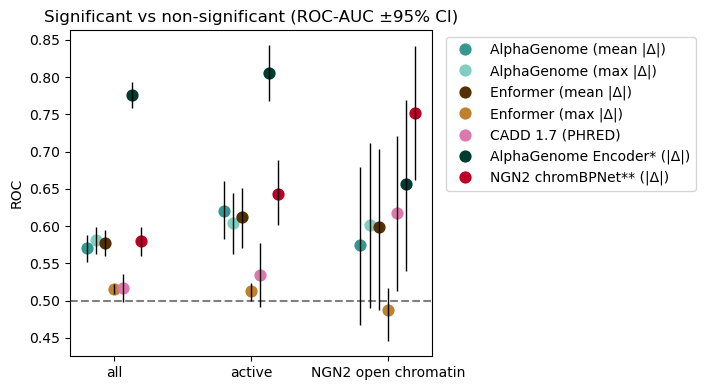

In [39]:
# plot only All, active elements and NGN2 open chromatin

perf_filtered = perf[perf["universe"].isin(["all", "active", "NGN2 open chromatin"])]
universe_order = ("all", "active", "brain cCREs", "NGN2 open chromatin")
plot_metric(
    perf_filtered,
    metric="ROC",
    lo="ROC_lo",
    hi="ROC_hi",
    title="Significant vs non-significant (ROC-AUC ±95% CI)",
    dodge=0.4,  # MUST match pointplot
    hue_order=list(MODEL_SCORES.keys()),
    universe_order=universe_order,
    capsize=0,  # set e.g. 3 if you want caps
    writing_out=True
)
# part of the paper

In [ ]:
# supplementary table
all_active_discrimination_roc_auc_path = "data/model_performance_tables/tables/model_performance_all_and_active_discrimination_roc_auc_PR.tsv.gz"
# perf
allele_frequency_roc_auc_path = "data/model_performance_tables/tables/model_performance_allele_frequency_roc_auc.tsv.gz"
# af_res
activity_roc_auc_path = "data/model_performance_tables/tables/model_performance_activity_roc_auc.tsv.gz"
# act_roc

In [41]:
print(perf.to_string())

               universe                       model      n   pos       ROC    ROC_lo    ROC_hi        PR     PR_lo     PR_hi
0                   all      AlphaGenome (mean |Δ|)  38968  1018  0.570288  0.551389  0.587645  0.034097  0.031695  0.037725
1                   all       AlphaGenome (max |Δ|)  38968  1018  0.580981  0.562783  0.598759  0.034870  0.032498  0.037862
2                   all         Enformer (mean |Δ|)  38968  1018  0.577960  0.560516  0.595305  0.034404  0.032084  0.038089
3                   all          Enformer (max |Δ|)  38968  1018  0.515608  0.508744  0.521799  0.026963  0.026610  0.027310
4                   all            CADD 1.7 (PHRED)  38968  1018  0.516588  0.497692  0.535221  0.028782  0.026942  0.031133
5                   all  AlphaGenome Encoder* (|Δ|)  38968  1018  0.776236  0.758967  0.793464  0.265468  0.236722  0.294059
6                   all     NGN2 chromBPNet** (|Δ|)  38968  1018  0.579737  0.560324  0.598896  0.063621  0.053369  0.078171


In [ ]:
def figure5_panel_A2_PR(perf, writing_out=False, universe_order = ["all", "active"]):

    hue_order = list(MODEL_SCORES.keys())
    dodge = 0.4

    d = perf.copy()
    universe_order = [u for u in universe_order if u in d["universe"].unique()]

    d["universe"] = pd.Categorical(
        d["universe"], categories=universe_order, ordered=True
    )
    d["model"] = pd.Categorical(d["model"], categories=hue_order, ordered=True)
    d = d.sort_values(["universe", "model"])

    plt.figure(figsize=(5, 4))


    ax = sns.pointplot(
        data=d,
        x="universe",
        y="PR",
        hue="model",
        order=universe_order,
        hue_order=hue_order,
        palette=MODEL_COLORS,
        dodge=dodge,
        join=False,
        errorbar=None,
    )

    add_black_errorbars(
        ax,
        d,
        x_col="universe",
        y_col="PR",
        lo_col="PR_lo",
        hi_col="PR_hi",
        x_order=universe_order,
        hue_order=hue_order,
        dodge=dodge,
    )

    # Draw a subtle prevalence baseline for each universe group
    prevalence = (
        d.groupby("universe", observed=True)[["pos", "n"]]
        .first()
        .assign(prev=lambda df: df["pos"] / df["n"])
    )
    for i, universe in enumerate(universe_order):
        if universe in prevalence.index:
            prev = prevalence.loc[universe, "prev"]
            ax.hlines(
                prev,
                xmin=i - dodge / 2,
                xmax=i + dodge / 2,
                colors="gray",
                linewidths=1.2,
                linestyles="--",
                label="Prevalence/Baseline" if i == 0 else "_nolegend_",
                zorder=1,
            )


    ax.set_ylabel("PR-AUC")
    ax.set_xlabel("")
    ax.set_title("Precision–recall performance")

    # plot legend outside
    # ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

    ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")


    # plt.tight_layout()
    # store the figure as png and svg
    output_path = "data/model_performance_tables/"
    if writing_out:
        file_name = os.path.join(output_path, "2604_precision_recall_all_vs_active")
        plt.savefig(
            file_name + ".png", dpi=300, bbox_inches="tight"
        )
        plt.savefig(
            file_name + ".svg", dpi=300, bbox_inches="tight"
        )
    plt.show()

In [44]:
print(perf_filtered.head().to_string())

  universe                   model      n   pos       ROC    ROC_lo    ROC_hi        PR     PR_lo     PR_hi
0      all  AlphaGenome (mean |Δ|)  38968  1018  0.570288  0.551389  0.587645  0.034097  0.031695  0.037725
1      all   AlphaGenome (max |Δ|)  38968  1018  0.580981  0.562783  0.598759  0.034870  0.032498  0.037862
2      all     Enformer (mean |Δ|)  38968  1018  0.577960  0.560516  0.595305  0.034404  0.032084  0.038089
3      all      Enformer (max |Δ|)  38968  1018  0.515608  0.508744  0.521799  0.026963  0.026610  0.027310
4      all        CADD 1.7 (PHRED)  38968  1018  0.516588  0.497692  0.535221  0.028782  0.026942  0.031133


/tmp/ipykernel_98177/1218255111.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


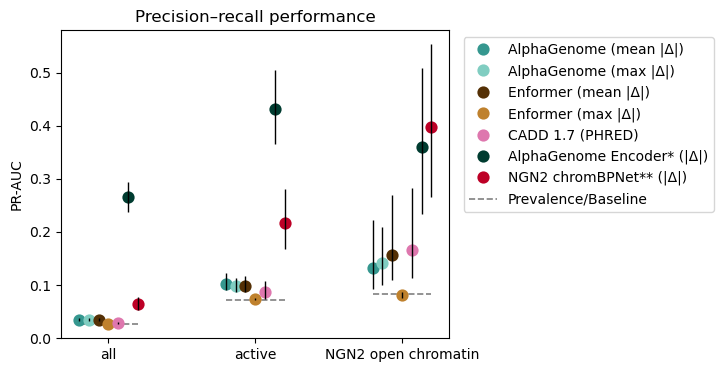

In [45]:
writing=False
# figure5_panel_A2_PR(perf, writing_out=writing, universe_order=["all", "active", "brain cCREs", "NGN2 open chromatin"])
figure5_panel_A2_PR(perf_filtered, writing_out=writing, universe_order=["all", "active", "brain cCREs", "NGN2 open chromatin"])
# part of the paper

##### Allele frequency

In [ ]:
d = filter_active(df)

d = add_af_category(d)

rows = []

y = get_label(d)

for cat, sub in d.groupby("af_category", observed=True):

    y_sub = y.loc[sub.index]

    for model, col in MODEL_SCORES.items():

        roc, lo, hi = bootstrap_ci(y_sub, sub[col], roc_fn)

        rows.append({
            "AF": cat,
            "model": model,
            "ROC": roc,
            "lo": lo,
            "hi": hi,
            "n": len(sub),
            "pos": int(y_sub.sum()),
        })

af_res = pd.DataFrame(rows)
# takes ~1 min

/tmp/ipykernel_98177/1303784799.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


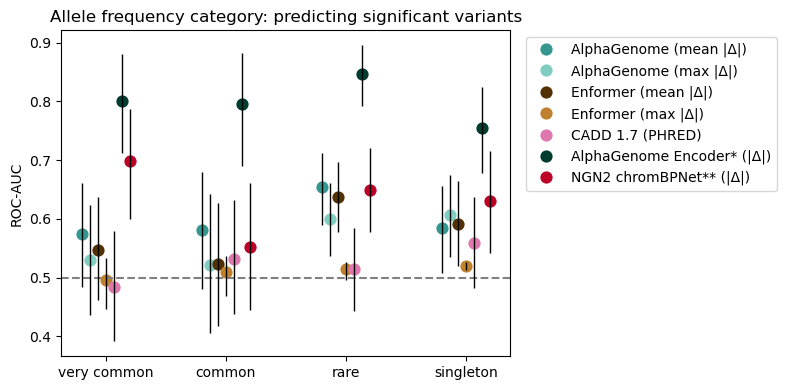

In [46]:
# Goal: ROC-AUC ±CI by AF category (active regions) with PERFECT alignment

# --- Ensure ordered categories are respected ---
af_order = ["very common", "common", "rare", "singleton"]
hue_order = list(MODEL_SCORES.keys())

af_res["AF"] = pd.Categorical(af_res["AF"], categories=af_order, ordered=True)
af_res["model"] = pd.Categorical(af_res["model"], categories=hue_order, ordered=True)
af_res = af_res.sort_values(["AF", "model"])

dodge = 0.4
n_models = len(hue_order)

# exact seaborn-style offsets
if n_models == 1:
    offsets = np.array([0.0])
else:
    offsets = np.linspace(-dodge / 2, dodge / 2, n_models)

af_to_x = {cat: i for i, cat in enumerate(af_order)}
model_to_offset = {m: offsets[i] for i, m in enumerate(hue_order)}

plt.figure(figsize=(8, 4))

ax = sns.pointplot(
    data=af_res,
    x="AF",
    y="ROC",
    hue="model",
    order=af_order,
    hue_order=hue_order,
    palette=MODEL_COLORS,
    dodge=0.4,
    join=False,
    errorbar=None,
)

add_black_errorbars(
    ax,
    af_res,
    x_col="AF",
    y_col="ROC",
    lo_col="lo",
    hi_col="hi",
    x_order=af_order,
    hue_order=hue_order,
    dodge=0.4,
)


plt.axhline(0.5, ls="--", color="gray")
plt.title("Allele frequency category: predicting significant variants")
plt.ylabel("ROC-AUC")
plt.xlabel("")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


# store the figure as png and svg
output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/model_performance"
writing = True
if writing:
    file_name = os.path.join(output_path, "models_allele_frequencies_roc_auc")
    plt.savefig(file_name + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(file_name + ".svg", dpi=300, bbox_inches="tight")

plt.show()
# part of the paper

In [47]:
print(af_res.to_string())

             AF                       model       ROC        lo        hi    n  pos
0   very common      AlphaGenome (mean |Δ|)  0.573648  0.484381  0.660588  687   40
1   very common       AlphaGenome (max |Δ|)  0.529463  0.436028  0.624155  687   40
2   very common         Enformer (mean |Δ|)  0.547643  0.461242  0.637060  687   40
3   very common          Enformer (max |Δ|)  0.495247  0.446321  0.533230  687   40
4   very common            CADD 1.7 (PHRED)  0.483964  0.391184  0.579580  687   40
5   very common  AlphaGenome Encoder* (|Δ|)  0.800715  0.712489  0.881550  687   40
6   very common     NGN2 chromBPNet** (|Δ|)  0.699266  0.599918  0.786435  687   40
7        common      AlphaGenome (mean |Δ|)  0.580490  0.480443  0.679431  535   27
8        common       AlphaGenome (max |Δ|)  0.521471  0.405108  0.641770  535   27
9        common         Enformer (mean |Δ|)  0.522674  0.417396  0.627811  535   27
10       common          Enformer (max |Δ|)  0.510134  0.468717  0.536417  5

In [48]:
# Goal: PR-AUC ±95% CI by AF category (active regions)

d = add_af_category(filter_active(df))
y = get_label(d)

rows = []

for cat, sub in d.groupby("af_category", observed=True):
    y_sub = y.loc[sub.index]

    for model, col in MODEL_SCORES.items():
        pr, lo, hi = bootstrap_ci(y_sub, sub[col], pr_fn)

        rows.append({
            "AF": cat,
            "model": model,
            "PR": pr,
            "lo": lo,
            "hi": hi,
            "n": len(sub),
            "pos": int(y_sub.sum()),
        })

af_pr = pd.DataFrame(rows)
# takes over 30 seconds

In [49]:
af_pr

,AF,model,PR,lo,hi,n,pos
0,very common,AlphaGenome (mean |Δ|),0.074227,0.059133,0.113979,687,40
1,very common,AlphaGenome (max |Δ|),0.073042,0.054537,0.118993,687,40
2,very common,Enformer (mean |Δ|),0.069126,0.054805,0.113072,687,40
3,very common,Enformer (max |Δ|),0.057767,0.053188,0.061920,687,40
4,very common,CADD 1.7 (PHRED),0.066862,0.049801,0.113804,687,40
5,very common,AlphaGenome Encoder* (|Δ|),0.443288,0.308215,0.603189,687,40
6,very common,NGN2 chromBPNet** (|Δ|),0.278316,0.162908,0.419586,687,40
7,common,AlphaGenome (mean |Δ|),0.069865,0.050741,0.145104,535,27
8,common,AlphaGenome (max |Δ|),0.072815,0.047947,0.137566,535,27
9,common,Enformer (mean |Δ|),0.053198,0.043938,0.082565,535,27


/tmp/ipykernel_98177/4281896536.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


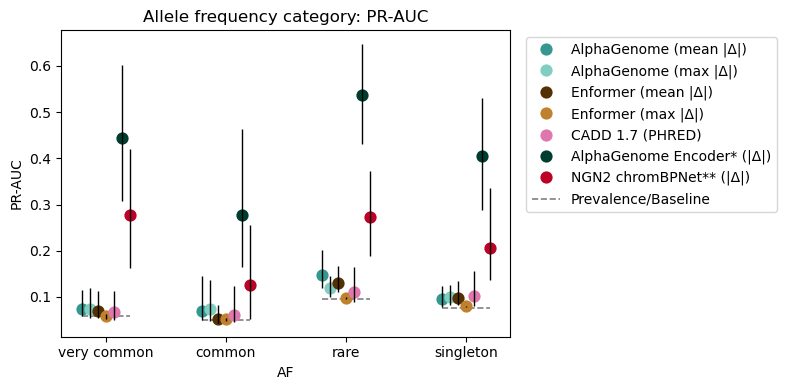

In [ ]:
af_order = ["very common", "common", "rare", "singleton"]
hue_order = list(MODEL_SCORES.keys())

plt.figure(figsize=(8, 4))

ax = sns.pointplot(
    data=af_pr,
    x="AF",
    y="PR",
    hue="model",
    order=af_order,
    hue_order=hue_order,
    palette=MODEL_COLORS,
    dodge=0.4,
    join=False,
    errorbar=None,
)

add_black_errorbars(
    ax,
    af_pr,
    x_col="AF",
    y_col="PR",
    lo_col="lo",
    hi_col="hi",
    x_order=af_order,
    hue_order=hue_order,
    dodge=0.4,
)


# Draw a subtle prevalence baseline for each universe group
prevalence = (
    af_pr.groupby("AF", observed=True)[["pos", "n"]]
    .first()
    .assign(prev=lambda df: df["pos"] / df["n"])
)
for i, universe in enumerate(af_order):
    if universe in prevalence.index:
        prev = prevalence.loc[universe, "prev"]
        ax.hlines(
            prev,
            xmin=i - dodge / 2,
            xmax=i + dodge / 2,
            colors="gray",
            linewidths=1.2,
            linestyles="--",
            label="Prevalence/Baseline" if i == 0 else "_nolegend_",
            zorder=1,
        )

plt.ylabel("PR-AUC")
plt.title("Allele frequency category: PR-AUC")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# store the figure as png and svg
output_path = "data/model_performance_tables/"
writing = False
if writing:
    file_name = os.path.join(output_path, "2604_models_allele_frequencies_pr_auc")
    plt.savefig(file_name + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(file_name + ".svg", dpi=300, bbox_inches="tight")

plt.show()

In [51]:
print(af_pr.to_string())

             AF                       model        PR        lo        hi    n  pos
0   very common      AlphaGenome (mean |Δ|)  0.074227  0.059133  0.113979  687   40
1   very common       AlphaGenome (max |Δ|)  0.073042  0.054537  0.118993  687   40
2   very common         Enformer (mean |Δ|)  0.069126  0.054805  0.113072  687   40
3   very common          Enformer (max |Δ|)  0.057767  0.053188  0.061920  687   40
4   very common            CADD 1.7 (PHRED)  0.066862  0.049801  0.113804  687   40
5   very common  AlphaGenome Encoder* (|Δ|)  0.443288  0.308215  0.603189  687   40
6   very common     NGN2 chromBPNet** (|Δ|)  0.278316  0.162908  0.419586  687   40
7        common      AlphaGenome (mean |Δ|)  0.069865  0.050741  0.145104  535   27
8        common       AlphaGenome (max |Δ|)  0.072815  0.047947  0.137566  535   27
9        common         Enformer (mean |Δ|)  0.053198  0.043938  0.082565  535   27
10       common          Enformer (max |Δ|)  0.051505  0.047791  0.054217  5

In [52]:
# Goal: ROC-AUC ±95% CI by activity quartile (active regions)

d = filter_active(df).copy()
d["abs_activity"] = d[CFG["activity"]].abs()
d["activity_q4"] = pd.qcut(d["abs_activity"], q=4, duplicates="drop")
# round the activity bin label
d["rounded_activity_q4"] = d["activity_q4"].apply(lambda x: f"[{x.left:.2f}, {x.right:.2f}]")

y = get_label(d)

rows = []

for q, sub in d.groupby("rounded_activity_q4", observed=True):
    y_sub = y.loc[sub.index]

    for model, col in MODEL_SCORES.items():
        roc, lo, hi = bootstrap_ci(y_sub, sub[col], roc_fn)

        rows.append({
            "activity_bin": str(q),
            "model": model,
            "ROC": roc,
            "lo": lo,
            "hi": hi,
            "n": len(sub),
            "pos": int(y_sub.sum()),
        })

act_roc = pd.DataFrame(rows)

# takes over 1 minute

/tmp/ipykernel_98177/2067165288.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


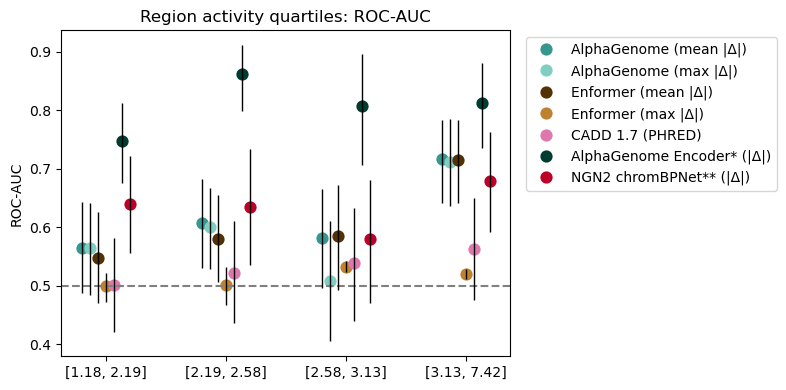

In [ ]:
activity_order = sorted(act_roc["activity_bin"].unique())
hue_order = list(MODEL_SCORES.keys())
dodge = 0.4

plt.figure(figsize=(8, 4))

ax = sns.pointplot(
    data=act_roc,
    x="activity_bin",
    y="ROC",
    hue="model",
    order=activity_order,
    hue_order=hue_order,
    palette=MODEL_COLORS,
    dodge=dodge,
    join=False,
    errorbar=None,
)

add_black_errorbars(
    ax,
    act_roc,
    x_col="activity_bin",
    y_col="ROC",
    lo_col="lo",
    hi_col="hi",
    x_order=activity_order,
    hue_order=hue_order,
    dodge=dodge,
)

ax.axhline(0.5, ls="--", color="gray")
ax.set_ylabel("ROC-AUC")
# ax.set_xlabel("Activity quartile")
plt.xlabel("")
ax.set_title("Region activity quartiles: ROC-AUC")
# plt.xticks(rotation=30)
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# store the figure as png and svg
output_path = "data/model_performance_tables/"
writing = False
if writing:
    file_name = os.path.join(output_path, "models_activity_quartiles_roc_auc")
    plt.savefig(
        file_name + ".png", dpi=300, bbox_inches="tight"
    )
    plt.savefig(
        file_name + ".svg", dpi=300, bbox_inches="tight"
    )

plt.show()
# part of the paper

In [54]:
print(act_roc.to_string())

    activity_bin                       model       ROC        lo        hi    n  pos
0   [1.18, 2.19]      AlphaGenome (mean |Δ|)  0.564172  0.487312  0.642298  678   57
1   [1.18, 2.19]       AlphaGenome (max |Δ|)  0.563819  0.483413  0.640848  678   57
2   [1.18, 2.19]         Enformer (mean |Δ|)  0.548013  0.471161  0.625878  678   57
3   [1.18, 2.19]          Enformer (max |Δ|)  0.500198  0.471647  0.521739  678   57
4   [1.18, 2.19]            CADD 1.7 (PHRED)  0.500537  0.420076  0.580803  678   57
5   [1.18, 2.19]  AlphaGenome Encoder* (|Δ|)  0.747662  0.676142  0.811930  678   57
6   [1.18, 2.19]     NGN2 chromBPNet** (|Δ|)  0.639461  0.556478  0.722016  678   57
7   [2.19, 2.58]      AlphaGenome (mean |Δ|)  0.606561  0.530379  0.682709  678   50
8   [2.19, 2.58]       AlphaGenome (max |Δ|)  0.600350  0.529198  0.666370  678   50
9   [2.19, 2.58]         Enformer (mean |Δ|)  0.579522  0.505693  0.655298  678   50
10  [2.19, 2.58]          Enformer (max |Δ|)  0.501704  0.466337 

In [55]:
# activity bin roc difference
# assuming your dataframe is called act_roc

# get the first (lowest quartile) and last (highest quartile) activity bins
lowest_bin = act_roc["activity_bin"].iloc[0]
highest_bin = act_roc["activity_bin"].iloc[-1]

# extract ROC values for lowest and highest quartile
low = (
    act_roc[act_roc["activity_bin"] == lowest_bin]
    .set_index("model")["ROC"]
)

high = (
    act_roc[act_roc["activity_bin"] == highest_bin]
    .set_index("model")["ROC"]
)

# compute difference
roc_diff = (high - low).reset_index()
roc_diff.columns = ["model", "ROC_difference_high_minus_low"]

print(roc_diff.to_string(index=False))

                     model  ROC_difference_high_minus_low
    AlphaGenome (mean |Δ|)                       0.151737
     AlphaGenome (max |Δ|)                       0.147987
       Enformer (mean |Δ|)                       0.166724
        Enformer (max |Δ|)                       0.019283
          CADD 1.7 (PHRED)                       0.062369
AlphaGenome Encoder* (|Δ|)                       0.064342
   NGN2 chromBPNet** (|Δ|)                       0.039291


Precision recall values per model: 

In [56]:
def plot_pr_with_ci(
    perf_df,
    title="Significant vs non-significant (PR-AUC ±95% CI)",
    universe_order=("all", "active"),
    dodge=0.4,
):
    d = perf_df.copy()

    # consistent ordering
    hue_order = list(MODEL_SCORES.keys())
    universe_order = [u for u in universe_order if u in d["universe"].unique()]

    d["universe"] = pd.Categorical(
        d["universe"], categories=universe_order, ordered=True
    )
    d["model"] = pd.Categorical(d["model"], categories=hue_order, ordered=True)
    d = d.sort_values(["universe", "model"])

    # seaborn-compatible offsets
    n_models = len(hue_order)
    if n_models == 1:
        offsets = np.array([0.0])
    else:
        offsets = np.linspace(-dodge / 2, dodge / 2, n_models)

    universe_to_x = {u: i for i, u in enumerate(universe_order)}
    model_to_offset = {m: offsets[i] for i, m in enumerate(hue_order)}

    plt.figure(figsize=(7.2, 4))

    ax = sns.pointplot(
        data=d,
        x="universe",
        y="PR",
        hue="model",
        order=universe_order,
        hue_order=hue_order,
        palette=MODEL_COLORS,
        dodge=dodge,
        join=False,
        errorbar=None,
    )

    add_black_errorbars(
        ax,
        d,
        x_col="universe",
        y_col="PR",
        lo_col="PR_lo",
        hi_col="PR_hi",
        x_order=universe_order,
        hue_order=hue_order,
        dodge=0.4,
    )

    # --- Baseline (prevalence) ---
    for u in universe_order:
        sub = d[d["universe"] == u]
        if len(sub) > 0:
            prev = sub["pos"].iloc[0] / sub["n"].iloc[0]
            ax.axhline(prev, ls="--", color="gray", linewidth=1)

    ax.set_ylabel("PR-AUC (Average Precision)")
    ax.set_xlabel("")
    ax.set_title(title)
    ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

In [60]:
# perf_display = perf.sort_values(["universe", "PR"], ascending=[True, False])

# print(
#     perf_display[
#         [
#             "universe",
#             "model",
#             "n",
#             "PR",
#             "PR_lo",
#             "PR_hi",
#             "ROC",
#             "ROC_lo",
#             "ROC_hi",
#         ]
#     ].to_string(index=False)
# )

# plot_pr_with_ci(perf)


Per quanitile 

In [57]:
# Goal: PR-AUC ±95% CI by activity quartile (active regions)

d = filter_active(df).copy()
d["abs_activity"] = d[CFG["activity"]].abs()

d["activity_q4"] = pd.qcut(d["abs_activity"], q=4, duplicates="drop")
# round the activity bin label
d["rounded_activity_q4"] = d["activity_q4"].apply(lambda x: f"[{x.left:.2f}, {x.right:.2f}]")


y = get_label(d)

rows = []

for q, sub in d.groupby("rounded_activity_q4", observed=True):
    y_sub = y.loc[sub.index]

    for model, col in MODEL_SCORES.items():
        pr, lo, hi = bootstrap_ci(y_sub, sub[col], pr_fn)

        rows.append(
            {
                "activity_bin": str(q),
                "model": model,
                "PR": pr,
                "lo": lo,
                "hi": hi,
                "n": len(sub),
                "pos": int(y_sub.sum()),
            }
        )

act_pr = pd.DataFrame(rows)

In [ ]:
# supplementary table
all_active_discrimination_roc_pr_auc_path = "data/model_performance_tables/tables/model_performance_all_and_active_discrimination_roc_auc_PR.tsv.gz"
all_active_discrimination_roc_pr_auc_path = "data/model_performance_tables/tables/2604_model_performance_all_and_active_discrimination_roc_auc_PR.tsv.gz"
# perf
allele_frequency_roc_auc_path = "data/model_performance_tables/tables/model_performance_allele_frequency_roc_auc.tsv.gz"
allele_frequency_roc_auc_path = "data/model_performance_tables/tables/2604_model_performance_allele_frequency_roc_auc.tsv.gz"
# af_res
allele_frequency_pr_auc_path = "data/model_performance_tables/tables/model_performance_allele_frequency_pr_auc.tsv.gz"
allele_frequency_pr_auc_path = "data/model_performance_tables/tables/2604_model_performance_allele_frequency_pr_auc.tsv.gz"
# af_pr
activity_roc_auc_path = "data/model_performance_tables/tables/model_performance_activity_roc_auc.tsv.gz"
activity_roc_auc_path = "data/model_performance_tables/tables/2604_model_performance_activity_roc_auc.tsv.gz"
# act_roc
activity_pr_auc_path = "data/model_performance_tables/tables/model_performance_activity_pr_auc.tsv.gz"
activity_pr_auc_path = "data/model_performance_tables/tables/2604_model_performance_activity_pr_auc.tsv.gz"
# act_pr

writing = False
if writing:
    perf.to_csv(all_active_discrimination_roc_pr_auc_path, sep="\t", index=False, compression="gzip")
    af_res.to_csv(allele_frequency_roc_auc_path, sep="\t", index=False, compression="gzip")
    af_pr.to_csv(allele_frequency_pr_auc_path, sep="\t", index=False, compression="gzip")
    act_roc.to_csv(activity_roc_auc_path, sep="\t", index=False, compression="gzip")
    act_pr.to_csv(activity_pr_auc_path, sep="\t", index=False, compression="gzip")

In [59]:
act_pr

,activity_bin,model,PR,lo,hi,n,pos
0,"[1.18, 2.19]",AlphaGenome (mean |Δ|),0.101990,0.083603,0.146827,678,57
1,"[1.18, 2.19]",AlphaGenome (max |Δ|),0.097972,0.083269,0.126260,678,57
2,"[1.18, 2.19]",Enformer (mean |Δ|),0.094941,0.080447,0.129417,678,57
3,"[1.18, 2.19]",Enformer (max |Δ|),0.084124,0.080006,0.087427,678,57
4,"[1.18, 2.19]",CADD 1.7 (PHRED),0.091784,0.073895,0.134268,678,57
5,"[1.18, 2.19]",AlphaGenome Encoder* (|Δ|),0.357257,0.244595,0.479264,678,57
6,"[1.18, 2.19]",NGN2 chromBPNet** (|Δ|),0.200709,0.132976,0.302955,678,57
7,"[2.19, 2.58]",AlphaGenome (mean |Δ|),0.098405,0.080392,0.134036,678,50
8,"[2.19, 2.58]",AlphaGenome (max |Δ|),0.088845,0.075457,0.112023,678,50
9,"[2.19, 2.58]",Enformer (mean |Δ|),0.086692,0.073339,0.111743,678,50


/tmp/ipykernel_98177/3560982698.py:6: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


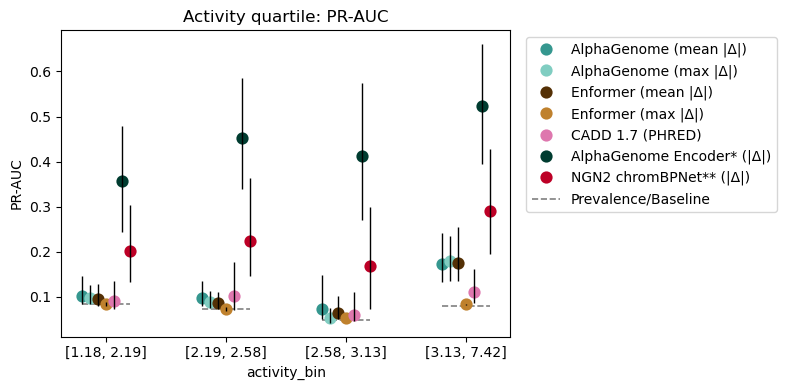

In [60]:
activity_order = sorted(act_pr["activity_bin"].unique())
hue_order = list(MODEL_SCORES.keys())

plt.figure(figsize=(8, 4))

ax = sns.pointplot(
    data=act_pr,
    x="activity_bin",
    y="PR",
    hue="model",
    order=activity_order,
    hue_order=hue_order,
    palette=MODEL_COLORS,
    dodge=0.4,
    join=False,
    errorbar=None,
)

add_black_errorbars(
    ax,
    act_pr,
    x_col="activity_bin",
    y_col="PR",
    lo_col="lo",
    hi_col="hi",
    x_order=activity_order,
    hue_order=hue_order,
    dodge=0.4,
)

# Draw a subtle prevalence baseline for each universe group
prevalence = (
    act_pr.groupby("activity_bin", observed=True)[["pos", "n"]]
    .first()
    .assign(prev=lambda df: df["pos"] / df["n"])
)
for i, universe in enumerate(activity_order):
    if universe in prevalence.index:
        prev = prevalence.loc[universe, "prev"]
        ax.hlines(
            prev,
            xmin=i - dodge / 2,
            xmax=i + dodge / 2,
            colors="gray",
            linewidths=1.2,
            linestyles="--",
            label="Prevalence/Baseline" if i == 0 else "_nolegend_",
            zorder=1,
        )

plt.ylabel("PR-AUC")
plt.title("Activity quartile: PR-AUC")
# plt.xticks(rotation=30)
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# store the figure as png and svg
output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/model_performance"
writing = True
if writing:
    file_name = os.path.join(output_path, "2604_models_activity_quartiles_pr_auc")
    plt.savefig(
        file_name + ".png", dpi=300, bbox_inches="tight"
    )
    plt.savefig(
        file_name + ".svg", dpi=300, bbox_inches="tight"
    )
plt.show()

# part of the paper

Combined into ROC all vs Active and PR All vs Active and  

In [61]:
def figure5_panel_A1_ROC(perf, universe_order = ["all", "active"]):
    hue_order = list(MODEL_SCORES.keys())
    dodge = 0.4

    d = perf.copy()
    d["universe"] = pd.Categorical(
        d["universe"], categories=universe_order, ordered=True
    )
    d["model"] = pd.Categorical(d["model"], categories=hue_order, ordered=True)
    d = d.sort_values(["universe", "model"])

    plt.figure(figsize=(4.5, 4))

    ax = sns.pointplot(
        data=d,
        x="universe",
        y="ROC",
        hue="model",
        order=universe_order,
        hue_order=hue_order,
        palette=MODEL_COLORS,
        dodge=dodge,
        join=False,
        errorbar=None,
    )

    add_black_errorbars(
        ax,
        d,
        x_col="universe",
        y_col="ROC",
        lo_col="ROC_lo",
        hi_col="ROC_hi",
        x_order=universe_order,
        hue_order=hue_order,
        dodge=dodge,
    )

    ax.axhline(0.5, ls="--", color="gray")
    ax.set_ylabel("ROC-AUC")
    ax.set_xlabel("")
    ax.set_title("Overall discrimination")
    ax.legend_.remove()

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_98177/1338273976.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


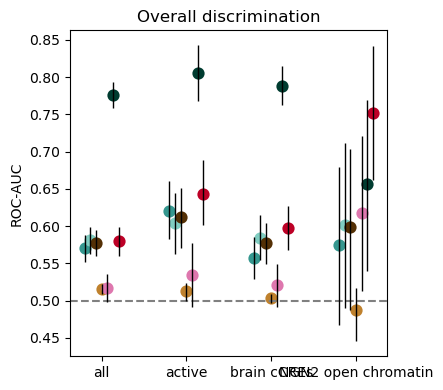

In [62]:
figure5_panel_A1_ROC(perf, universe_order=["all", "active", "brain cCREs", "NGN2 open chromatin"])

In [63]:
def figure5_panel_B_AF(af_roc, y_limits=None, writing_out=False):
    af_order = ["very common", "common", "rare", "singleton"]
    hue_order = list(MODEL_SCORES.keys())
    dodge = 0.4

    d = af_roc.copy()
    d["AF"] = pd.Categorical(d["AF"], categories=af_order, ordered=True)
    d["model"] = pd.Categorical(d["model"], categories=hue_order, ordered=True)
    d = d.sort_values(["AF", "model"])

    plt.figure(figsize=(5.5, 4))

    ax = sns.pointplot(
        data=d,
        x="AF",
        y="ROC",
        hue="model",
        order=af_order,
        hue_order=hue_order,
        palette=MODEL_COLORS,
        dodge=dodge,
        join=False,
        errorbar=None,
    )

    add_black_errorbars(
        ax,
        d,
        x_col="AF",
        y_col="ROC",
        lo_col="lo",
        hi_col="hi",
        x_order=af_order,
        hue_order=hue_order,
        dodge=dodge,
    )

    ax.axhline(0.5, ls="--", color="gray")
    ax.set_ylabel("ROC-AUC")
    ax.set_xlabel("Allele Frequency category")
    ax.set_title("Dependence on allele frequency")
    ax.legend_.remove()
    # y limit:
    if y_limits:
        ax.set_ylim(*y_limits)

    plt.tight_layout()
    # store the figure as png and svg
    output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/model_performance"
    if writing_out:
        file_name = os.path.join(output_path, "2604_allele_frequency_roc_auc")
        plt.savefig(
            file_name + ".png", dpi=300, bbox_inches="tight"
        )
        plt.savefig(
            file_name + ".svg", dpi=300, bbox_inches="tight"
        )

    plt.show()

/tmp/ipykernel_98177/249462920.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


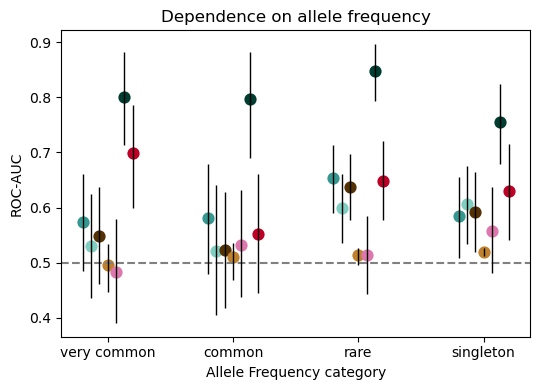

/tmp/ipykernel_98177/249462920.py:13: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


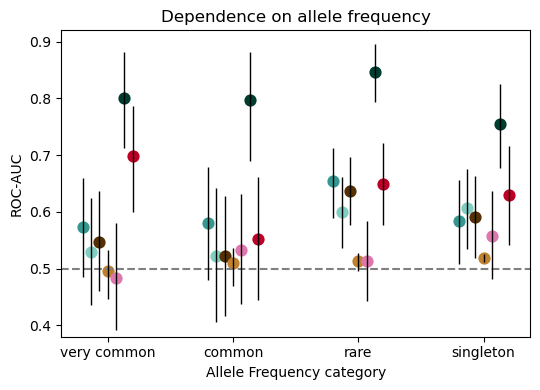

In [64]:
# writing = False
y_limits = (0.38, 0.92)
figure5_panel_B_AF(af_res)
figure5_panel_B_AF(af_res, y_limits=y_limits, writing_out=writing)

In [65]:
def figure5_panel_C_activity(act_roc, activity_order, y_limits=None, writing_out=False):
    hue_order = list(MODEL_SCORES.keys())
    dodge = 0.4

    d = act_roc.copy()
    d["activity_bin"] = pd.Categorical(
        d["activity_bin"], categories=activity_order, ordered=True
    )
    d["model"] = pd.Categorical(d["model"], categories=hue_order, ordered=True)
    d = d.sort_values(["activity_bin", "model"])

    plt.figure(figsize=(5.5, 4))

    ax = sns.pointplot(
        data=d,
        x="activity_bin",
        y="ROC",
        hue="model",
        order=activity_order,
        hue_order=hue_order,
        palette=MODEL_COLORS,
        dodge=dodge,
        join=False,
        errorbar=None,
    )

    add_black_errorbars(
        ax,
        d,
        x_col="activity_bin",
        y_col="ROC",
        lo_col="lo",
        hi_col="hi",
        x_order=activity_order,
        hue_order=hue_order,
        dodge=dodge,
    )

    ax.axhline(0.5, ls="--", color="gray")
    ax.set_ylabel("ROC-AUC")
    ax.set_xlabel("Activity quartile")
    ax.set_title("Dependence on regulatory activity")
    ax.legend_.remove()
    if y_limits:
        ax.set_ylim(*y_limits)
    # ax.set_ylim(0.4, 0.79)

    plt.tight_layout()
    # store the figure as png and svg
    output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/model_performance"
    if writing_out:
        file_name = os.path.join(output_path, "2604_activity_roc_auc")
        plt.savefig(
            file_name + ".png", dpi=300, bbox_inches="tight"
        )
        plt.savefig(
            file_name + ".svg", dpi=300, bbox_inches="tight"
        )
    plt.show()

In [66]:
act_roc

,activity_bin,model,ROC,lo,hi,n,pos
0,"[1.18, 2.19]",AlphaGenome (mean |Δ|),0.564172,0.487312,0.642298,678,57
1,"[1.18, 2.19]",AlphaGenome (max |Δ|),0.563819,0.483413,0.640848,678,57
2,"[1.18, 2.19]",Enformer (mean |Δ|),0.548013,0.471161,0.625878,678,57
3,"[1.18, 2.19]",Enformer (max |Δ|),0.500198,0.471647,0.521739,678,57
4,"[1.18, 2.19]",CADD 1.7 (PHRED),0.500537,0.420076,0.580803,678,57
5,"[1.18, 2.19]",AlphaGenome Encoder* (|Δ|),0.747662,0.676142,0.811930,678,57
6,"[1.18, 2.19]",NGN2 chromBPNet** (|Δ|),0.639461,0.556478,0.722016,678,57
7,"[2.19, 2.58]",AlphaGenome (mean |Δ|),0.606561,0.530379,0.682709,678,50
8,"[2.19, 2.58]",AlphaGenome (max |Δ|),0.600350,0.529198,0.666370,678,50
9,"[2.19, 2.58]",Enformer (mean |Δ|),0.579522,0.505693,0.655298,678,50


In [67]:
activity_order

['[1.18, 2.19]', '[2.19, 2.58]', '[2.58, 3.13]', '[3.13, 7.42]']

/tmp/ipykernel_98177/2056515077.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


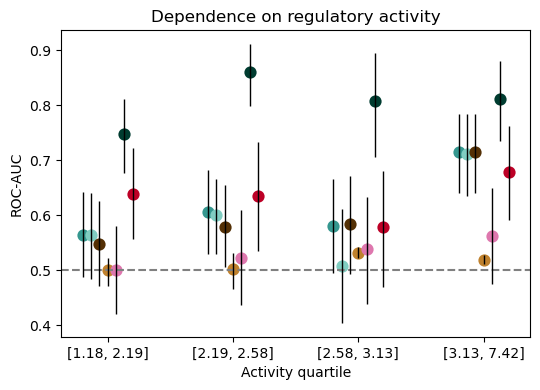

/tmp/ipykernel_98177/2056515077.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


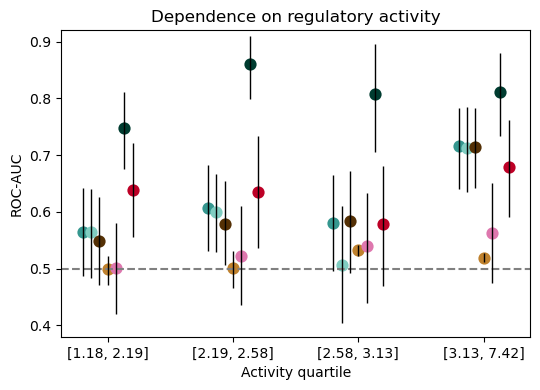

In [68]:
# writing=False
figure5_panel_C_activity(act_roc, activity_order)
figure5_panel_C_activity(act_roc, activity_order, y_limits=y_limits, writing_out=writing)
# part of the paper

Calibration

In [69]:
# Goal: calibration + interpretable OR per 1 SD


def calibration_analysis(universe_name, universe_fn):

    d = universe_fn(df)
    y = get_label(d).values

    print(f"\n=== Calibration: {universe_name} ===")
    print(f"n={len(d)}, prevalence={y.mean():.4f}")

    for model, col in MODEL_SCORES.items():
        s = d[col].values
        mask = np.isfinite(s)
        y2 = y[mask]
        s2 = s[mask]

        s_std = (s2 - np.mean(s2)) / np.std(s2)

        X = sm.add_constant(s_std)
        fit = sm.Logit(y2, X).fit(disp=0)

        beta = fit.params[1]
        or_val = np.exp(beta)
        ci_lo = np.exp(beta - 1.96 * fit.bse[1])
        ci_hi = np.exp(beta + 1.96 * fit.bse[1])

        print(f"\n{model}")
        print(f"OR per +1 SD: {or_val:.2f} (95% CI {ci_lo:.2f}-{ci_hi:.2f})")
        print(f"P-value: {fit.pvalues[1]:.2e}")
        print("Interpretation: multiplicative change in odds of being significant.")


calibration_analysis("all", filter_all)
calibration_analysis("active", filter_active)


=== Calibration: all ===
n=38968, prevalence=0.0261

AlphaGenome (mean |Δ|)
OR per +1 SD: 1.27 (95% CI 1.19-1.36)
P-value: 3.85e-13
Interpretation: multiplicative change in odds of being significant.

AlphaGenome (max |Δ|)
OR per +1 SD: 1.25 (95% CI 1.14-1.36)
P-value: 1.80e-06
Interpretation: multiplicative change in odds of being significant.

Enformer (mean |Δ|)
OR per +1 SD: 1.30 (95% CI 1.22-1.38)
P-value: 5.87e-18
Interpretation: multiplicative change in odds of being significant.

Enformer (max |Δ|)
OR per +1 SD: 1.14 (95% CI 1.05-1.24)
P-value: 1.95e-03
Interpretation: multiplicative change in odds of being significant.

CADD 1.7 (PHRED)
OR per +1 SD: 1.09 (95% CI 1.03-1.16)
P-value: 3.09e-03
Interpretation: multiplicative change in odds of being significant.

AlphaGenome Encoder* (|Δ|)
OR per +1 SD: 2.05 (95% CI 1.97-2.12)
P-value: 0.00e+00
Interpretation: multiplicative change in odds of being significant.

NGN2 chromBPNet** (|Δ|)
OR per +1 SD: 1.32 (95% CI 1.28-1.37)
P-valu

Effect size correlation
are the models good at predicting the effect size?

In [70]:
# Goal: Spearman correlation between score and |logFC|


def effect_corr(universe_name, universe_fn):

    d = universe_fn(df)
    eff = d[CFG["effect"]]

    print(f"\n=== Effect-size correlation: {universe_name} ===")

    for model, col in MODEL_SCORES.items():
        s = d[col]
        mask = np.isfinite(eff) & np.isfinite(s)

        r, p = spearmanr(s[mask], eff[mask])
        print(f"{model}: Spearman r={r:.3f}, p={p:.2e}")


effect_corr("all", filter_all)
effect_corr("active", filter_active)


=== Effect-size correlation: all ===
AlphaGenome (mean |Δ|): Spearman r=0.033, p=1.27e-10
AlphaGenome (max |Δ|): Spearman r=0.046, p=1.50e-19
Enformer (mean |Δ|): Spearman r=0.024, p=1.82e-06
Enformer (max |Δ|): Spearman r=0.017, p=9.95e-04
CADD 1.7 (PHRED): Spearman r=-0.004, p=3.79e-01
AlphaGenome Encoder* (|Δ|): Spearman r=0.134, p=1.78e-156
NGN2 chromBPNet** (|Δ|): Spearman r=0.015, p=3.09e-03

=== Effect-size correlation: active ===
AlphaGenome (mean |Δ|): Spearman r=0.062, p=1.25e-03
AlphaGenome (max |Δ|): Spearman r=0.082, p=1.92e-05
Enformer (mean |Δ|): Spearman r=0.059, p=2.05e-03
Enformer (max |Δ|): Spearman r=0.036, p=6.45e-02
CADD 1.7 (PHRED): Spearman r=0.019, p=3.32e-01
AlphaGenome Encoder* (|Δ|): Spearman r=0.233, p=9.05e-35
NGN2 chromBPNet** (|Δ|): Spearman r=0.070, p=2.79e-04
